In [13]:
import pandas as pd
import os

def smart_loader(data_source):
    # Identifies the file type and loads it appropriately
    
    # 1. Handle Partitioned Datasets (Dictionaries)
    if isinstance(data_source, dict):
        print("Partitioned dataset detected. Loading splits...")
        loaded_splits = {}
        for split_name, file_path in data_source.items():
            # Recursively call the loader for each file
            data, data_type = smart_loader(file_path)
            loaded_splits[split_name] = data
        return loaded_splits, f"{data_type}_split"

    # 2. File Existence Check (Fails fast if the path is wrong)
    if not os.path.exists(data_source):
        raise FileNotFoundError(f"Local file not found: {data_source}")

    # Extract extension for single files
    _, ext = os.path.splitext(data_source)
    ext = ext.lower()

    # 3. Handle Known Tabular Formats
    if ext == '.csv':
        print(f"Loading CSV file: {os.path.basename(data_source)}")
        return pd.read_csv(data_source), "tabular"
        
    elif ext in ['.xls', '.xlsx']:
        print(f"Loading Excel file: {os.path.basename(data_source)}")
        return pd.read_excel(data_source), "tabular"

    # 4. Handle Raw Binary MNIST Files (.ubyte)
    elif 'ubyte' in ext or 'ubyte' in data_source:
        print(f"Detected raw byte file: {os.path.basename(data_source)}")
        # Since this is local, we return the file path and a specific flag
        # so the next step in the pipeline knows it needs to be decoded.
        return data_source, "image_array_raw"

    # 5. Total Failure
    else:
        raise ValueError(f"Completely unsupported local format: {ext}")

In [12]:
# --- TEST 1: The Standard Load ---
print("=== TEST 1: Single File ===")
try:
    loan_df, flag = smart_loader('Datasets/Loan_Amount_Dataset/loan-train.csv')
    print(f"Success! Flag returned: '{flag}'")
    print(f"Data Shape: {loan_df.shape}")
    print("Preview:\n", loan_df.head(2))
except Exception as e:
    print(f"Test 1 Failed: {e}")

print("\n")

# --- TEST 2: The Dictionary Split ---
print("=== TEST 2: Partitioned Dictionary ===")
try:
    my_splits = {
        'train': 'Datasets/Loan_Amount_Dataset/loan-train.csv',
        'test': 'Datasets/Loan_Amount_Dataset/loan-test.csv'
    }
    split_data, split_flag = smart_loader(my_splits)
    print(f"Success! Flag returned: '{split_flag}'")
    print(f"Train set shape: {split_data['train'].shape}")
    print(f"Test set shape: {split_data['test'].shape}")
except Exception as e:
    print(f"Test 2 Failed: {e}")

print("\n")

# --- TEST 3: The Missing File Trap ---
print("=== TEST 3: Intentional Failure ===")
try:
    smart_loader('fake_typo_file.csv')
    print("Wait, this should have failed!")
except FileNotFoundError as e:
    print(f"Success! The trap worked. Caught error: {e}")
except Exception as e:
    print(f"Caught a different error: {e}")
print("\n")

# --- TEST 4: MNIST DATASET test ---
print("=== TEST 4: MNIST ===")
try:
    mnist_data, mnist_flag = smart_loader('Datasets/MNIST_Dataset/train-labels-idx1-ubyte')
    print(f"Success! Flag returned: '{mnist_flag}'")
    print(f"Data Payload: {mnist_data}")
except:
    print(f"MNIST Test Failed: {e}")

=== TEST 1: Single File ===
Loading CSV file: loan-train.csv
Success! Flag returned: 'tabular'
Data Shape: (614, 13)
Preview:
     Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001002   Male      No          0  Graduate            No   
1  LP001003   Male     Yes          1  Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  


=== TEST 2: Partitioned Dictionary ===
Partitioned dataset detected. Loading splits...
Loading CSV file: loan-train.csv
Loading CSV file: loan-test.csv
Success! Flag returned: 'tabular_split'
Train set shape: (614, 13)
Test set shape: (367, 12)


=== TEST 3: Intentional Failure ===
Success! The trap worked. Caught error: 

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def automated_eda(data, data_type):
    """
    Generates summary statistics and visualizations for tabular data.
    """
    if data_type != "tabular":
        print(f"Skipping tabular EDA. Received data type: {data_type}")
        return

    print("=== 1. SUMMARY STATISTICS ===")
    print(data.info())
    print("\n--- Descriptive Statistics ---")
    print(data.describe())
    
    # Isolate numerical columns to prevent seaborn errors with text data
    num_cols = data.select_dtypes(include=[np.number]).columns
    
    print("\n=== 2. VISUALIZATIONS ===")
    
    # A. Missing Values Heatmap 
    plt.figure(figsize=(10, 4))
    sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title("Missing Data Profile (Yellow = Missing)")
    plt.show()

    if len(num_cols) > 0:
        # B. Correlation Heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Feature Correlation Matrix")
        plt.show()
        
        # C. Histograms
        data[num_cols].hist(figsize=(12, 10), bins=20, edgecolor='black', color='skyblue')
        plt.suptitle("Numerical Feature Distributions")
        plt.show()

Starting EDA on Training Data...
=== 1. SUMMARY STATISTICS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

--- Descriptive Statistics ---
       Appli

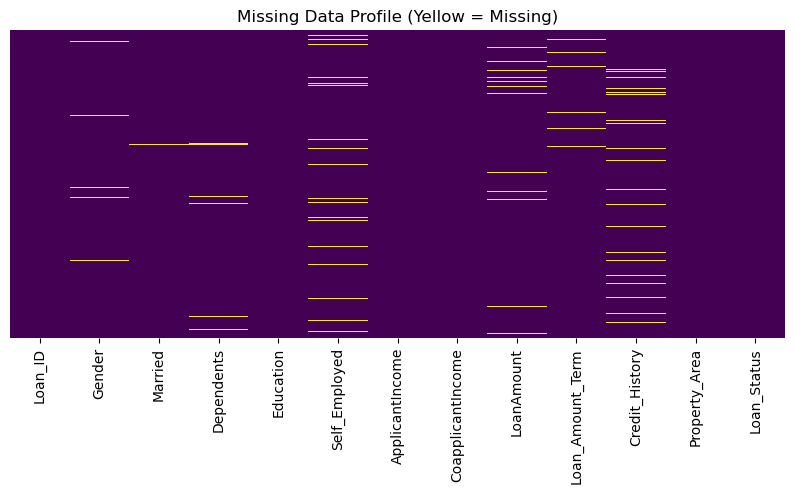

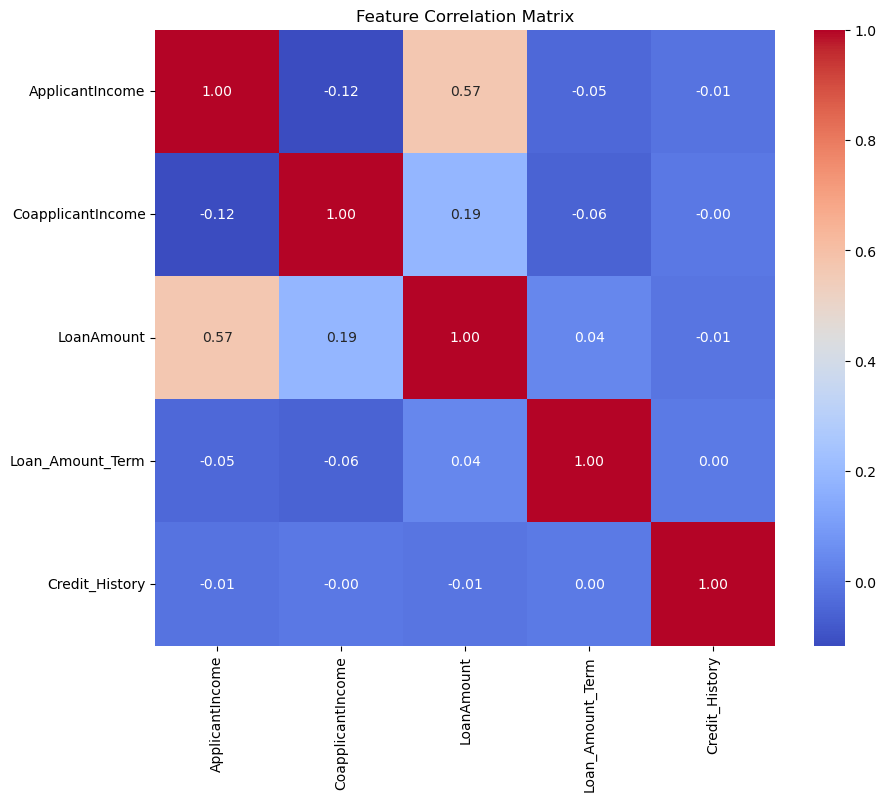

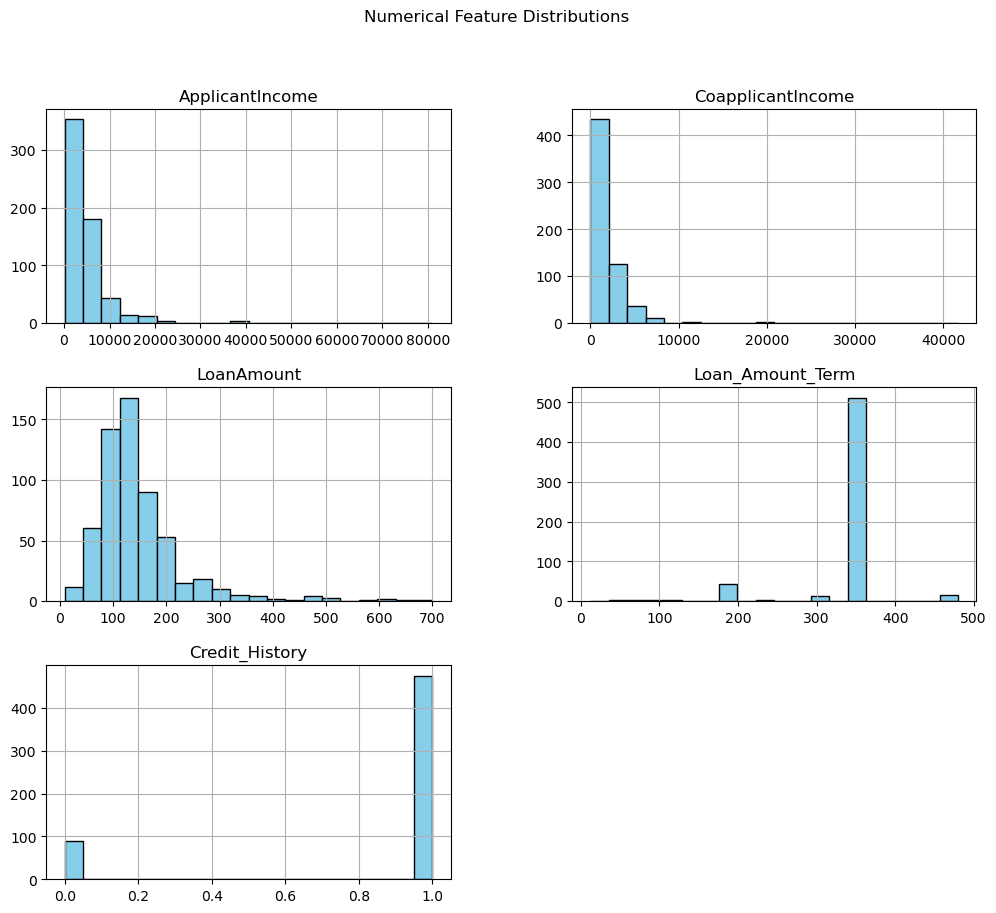

In [15]:
# Assuming you ran: loan_df, flag = smart_loader('Datasets/Loan_Amount_Dataset/loan-train.csv')

print("Starting EDA on Training Data...")
automated_eda(loan_df, flag)